In [20]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import pmdarima.arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [21]:
data_path = 'Impute_misvalues_hungyen1.csv'  
data = pd.read_csv(data_path)
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%d/%m/%Y %H:%M')

data.set_index('DateTime', inplace=True)

In [22]:
train_size = int(len(data) * 0.9)
train = data.iloc[:train_size, :]

In [23]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    for key, value in result[4].items():
        print('Critial Values:')
        print(f'   {key}, {value}')
check_stationarity(data['Waterlevel'])

ADF Statistic: -7.251277920680258
p-value: 1.7774156060489135e-10
Critial Values:
   1%, -3.4304521822576093
Critial Values:
   5%, -2.8615851626770272
Critial Values:
   10%, -2.566794038561404


In [35]:
start_date = pd.to_datetime('2014-02-13')
end_date = start_date + timedelta(hours=71)
true_values = data.loc[start_date:end_date, 'Waterlevel']

In [25]:
arima_model = pmdarima.arima.auto_arima(train['Waterlevel'], seasonal=False, 
                                        error_action='ignore', trace=True,
                                        suppress_warnings=True, maxiter=20, stepwise=True,
                                        n_jobs=2)

Performing stepwise search to minimize aic


C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=259962.391, Time=19.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=374517.930, Time=0.91 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=280220.616, Time=1.73 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=321281.216, Time=4.73 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=374515.941, Time=0.37 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=267993.345, Time=7.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=261235.850, Time=15.07 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=261309.472, Time=17.82 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=259530.307, Time=21.75 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=267187.894, Time=9.82 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=259459.481, Time=21.86 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=259223.685, Time=27.09 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=25.46 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=259322.910, Time=33.76 sec
 ARIMA(4,1,4)(0,0,0)[0] intercept   : AIC=25993

In [36]:
model_arima = ARIMA(train['Waterlevel'], order=arima_model.order)
model_arima_fit = model_arima.fit()
predictions_arima = model_arima_fit.predict(start=start_date, end=end_date, dynamic=True)

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local

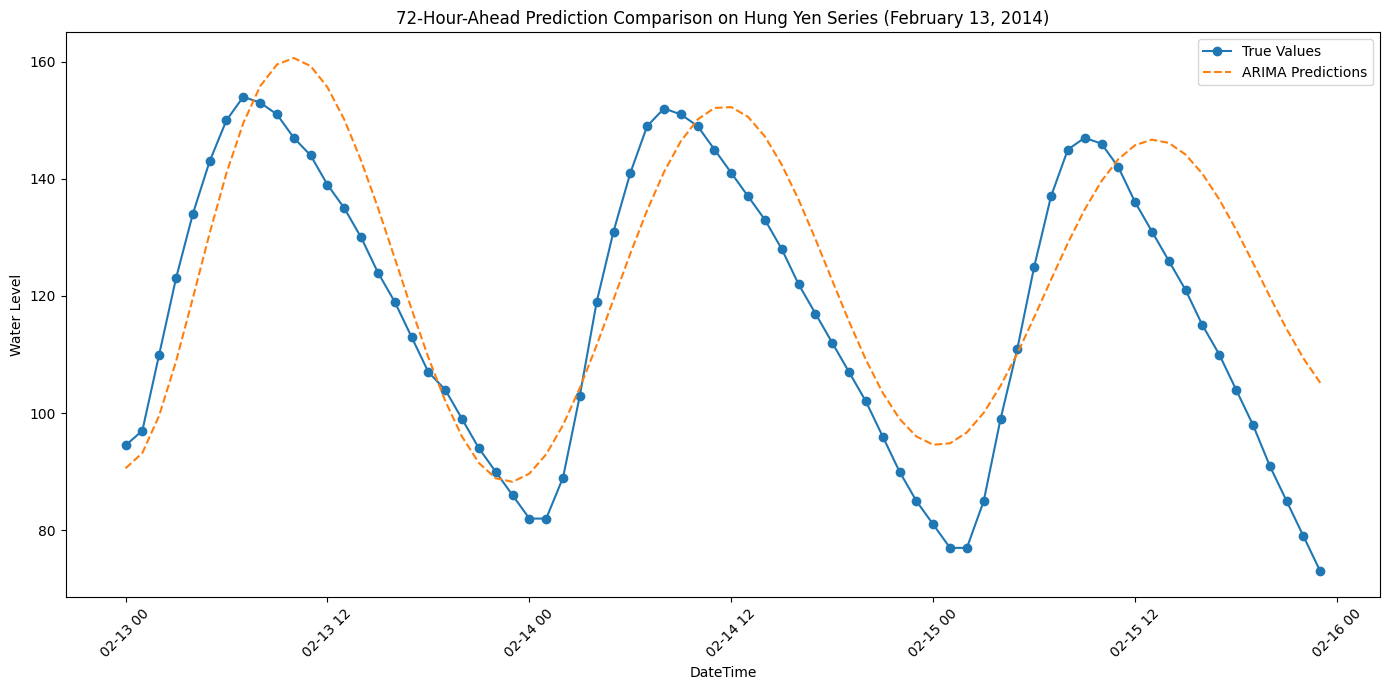

In [37]:
plt.figure(figsize=(14, 7))
plt.plot(true_values.index, true_values, label='True Values', marker='o')
plt.plot(true_values.index, predictions_arima, label='ARIMA Predictions', linestyle='--')
plt.legend()
plt.title('72-Hour-Ahead Prediction Comparison on Hung Yen Series (February 13, 2014)')
plt.xlabel('DateTime')
plt.ylabel('Water Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# Calculate MAE
mae = mean_absolute_error(true_values, predictions_arima)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(true_values, predictions_arima))

# Calculate FSD
fsd = np.std(predictions_arima - true_values) / np.std(true_values)

# Calculate Pearson Correlation Coefficient (R)
r, _ = pearsonr(true_values, predictions_arima)

# Calculate NSE
nse_numerator = np.sum((predictions_arima - true_values) ** 2)
nse_denominator = np.sum((true_values - np.mean(true_values)) ** 2)
nse = 1 - (nse_numerator / nse_denominator)

# Display the metrics
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"FSD: {fsd}")
print(f"R: {r}")
print(f"NSE: {nse}")

MAE: 11.897245041722861
RMSE: 14.203387966958207
FSD: 0.5304011481053038
R: 0.8495137421778709
NSE: 0.6499948451507342
